![](https://img.shields.io/badge/CNES_AVISO-Contribution-%20?color=grey&labelColor=blue)

# Using FCollections for Region of Interest Extraction

Half orbits intersecting the geographical areas are retrieved using Swot geometries, as in the {doc}`Search Swot tutorial <ex_search_swot>`.

The data is first downloaded using the [Altimetry Downloader Aviso](https://cnes.github.io/altimetry-downloader-aviso/) tool.

This script uses [fcollections](https://cnes.github.io/fcollections/) to clip each dataset according to a region of interest, then apply an export function. This export function applies the following modifications:

* The spatial and temporal location attributes are updated to reflect the region of interest
* The file history attributes are updated to trace the clipping modification
* If clipping a region results in no valid points remaining, the export is skipped

```{note}

Required environment to run this notebook:

* ``xarray``+``numpy``
* ``geopandas``+``numpy``
* ``matplotlib``+``shapely``
* ``dask``
* ``altimetry_downloader_aviso``: see [documentation](https://cnes.github.io/altimetry-downloader-aviso/).
* ``fcollections``: available [here](https://cnes.github.io/fcollections/).

In [1]:
from copy import copy
import functools
from pathlib import Path
import re
import typing as tp

import dask.distributed
from fcollections.core import Layout, FileNameConvention, FileNameFieldString
from fcollections.implementations import NetcdfFilesDatabaseSwotLRL3
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cartopy.crs as ccrs
import xarray as xr

import geopandas as gpd
from shapely import geometry

import logging

logging.basicConfig()
logger = logging.getLogger('crop_script')
logger.setLevel('DEBUG')

## Parameters

In [2]:
OUTPUT_FOLDER = Path.home() / "TMP_DATA"

QUERY = {
    "version": "3.0",
    "subset": "Expert",
    "cycle_number" : 40
    # Used to generate the samples. Can be removed
}

cycle_number = 40

AREAS = {
    # "polynesie": (-155, -28, -134, -7),
    "polynesie": (205, -28, 226, -7),
    "metropole": (-15, 34, 36, 54),
    "nvlle-caledonie": (158, -24, 167, -18),
    "outre-mer": (-63, 2, -51, 17)
}

## Get Half orbits intersecting the geographical areas

In [3]:
def get_half_orbits_intersect(bbox):
    """Get half orbits that intersect a bounding box.

    Parameters
    ----------
    bbox: 
        the bounding box
        
    Returns
    -------
     gpd.GeoDataFrame:
        A Geopandas dataframe containing intersecting half orbits numbers and geometries
    """
    swath_geometries = gpd.read_file(GEOMETRIES_FILE)

    bbox_polygon = geometry.box(*bbox)

    def _filter_intersect(row, polygon):
        half_orbit_polygon = row.geometry
        return polygon.intersects(half_orbit_polygon)

    select = swath_geometries.apply(_filter_intersect, polygon=bbox_polygon, axis=1)
    return swath_geometries[select]

In [4]:
GEOMETRIES_FILE = f'KaRIn_2kms_science_geometries.geojson'

In [5]:
pass_numbers = []

for area_name, area_box in AREAS.items():    
    swath_geoms = get_half_orbits_intersect(area_box)
    passes = list(swath_geoms.pass_number)
    print(f"Passes for {area_name}:")
    print(len(passes))
    
    pass_numbers = list(set(pass_numbers + passes))

Passes for polynesie:
42
Passes for metropole:
98
Passes for nvlle-caledonie:
19
Passes for outre-mer:
25


In [6]:
pass_numbers = sorted(pass_numbers)
len(pass_numbers)

184

## Download data using ``altimetry_downloader_aviso``

In [7]:
import altimetry_downloader_aviso as dl_aviso

In [8]:
dl_aviso.get(
    'SWOT_L3_LR_SSH_Expert', 
    output_dir=OUTPUT_FOLDER, 
    cycle_number=cycle_number, 
    pass_number=pass_numbers,
)

['/home/atonneau/TMP_DATA/SWOT_L3_LR_SSH_Expert_040_001_20251011T225152_20251011T234318_v3.0.nc',
 '/home/atonneau/TMP_DATA/SWOT_L3_LR_SSH_Expert_040_003_20251012T003445_20251012T012612_v3.0.nc',
 '/home/atonneau/TMP_DATA/SWOT_L3_LR_SSH_Expert_040_005_20251012T021739_20251012T030905_v3.0.nc',
 '/home/atonneau/TMP_DATA/SWOT_L3_LR_SSH_Expert_040_011_20251012T072620_20251012T081747_v3.0.nc',
 '/home/atonneau/TMP_DATA/SWOT_L3_LR_SSH_Expert_040_012_20251012T081747_20251012T090913_v3.0.nc',
 '/home/atonneau/TMP_DATA/SWOT_L3_LR_SSH_Expert_040_014_20251012T100041_20251012T105207_v3.0.nc',
 '/home/atonneau/TMP_DATA/SWOT_L3_LR_SSH_Expert_040_026_20251012T201803_20251012T210929_v3.0.nc',
 '/home/atonneau/TMP_DATA/SWOT_L3_LR_SSH_Expert_040_027_20251012T210929_20251012T220056_v3.0.nc',
 '/home/atonneau/TMP_DATA/SWOT_L3_LR_SSH_Expert_040_029_20251012T225223_20251012T234349_v3.0.nc',
 '/home/atonneau/TMP_DATA/SWOT_L3_LR_SSH_Expert_040_030_20251012T234350_20251013T003516_v3.0.nc',
 '/home/atonneau/TMP

## Extraction

In [9]:
cluster = dask.distributed.LocalCluster(processes=False)
client = cluster.get_client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://10.40.206.21:8787/status,
Dashboard: http://10.40.206.21:8787/status,Workers: 1
Total threads: 96,Total memory: 629.52 GiB
Status: running,Using processes: False
Comm: inproc://10.40.206.21/3754125/1,Workers: 1
Dashboard: http://10.40.206.21:8787/status,Total threads: 96
Started: Just now,Total memory: 629.52 GiB
Comm: inproc://10.40.206.21/3754125/4,Total threads: 96
Dashboard: http://10.40.206.21:42231/status,Memory: 629.52 GiB
Nanny: None,


INFO:crop_script:No valid data in half orbit (40, 110) for area 'polynesie', file will not be produced
DEBUG:crop_script:Creating /home/atonneau/TMP_DATA/SWOT_L3_LR_SSH_Expert_polynesie_040_082_20251014T201905_20251014T211032_v3.0.nc
DEBUG:crop_script:Creating /home/atonneau/TMP_DATA/SWOT_L3_LR_SSH_Expert_polynesie_040_554_20251031T170207_20251031T175333_v3.0.nc
DEBUG:crop_script:Creating /home/atonneau/TMP_DATA/SWOT_L3_LR_SSH_Expert_polynesie_040_416_20251026T184225_20251026T193351_v3.0.nc
DEBUG:crop_script:Creating /home/atonneau/TMP_DATA/SWOT_L3_LR_SSH_Expert_polynesie_040_039_20251013T072651_20251013T081818_v3.0.nc
DEBUG:crop_script:Creating /home/atonneau/TMP_DATA/SWOT_L3_LR_SSH_Expert_polynesie_040_401_20251026T055043_20251026T064209_v3.0.nc
DEBUG:crop_script:Creating /home/atonneau/TMP_DATA/SWOT_L3_LR_SSH_Expert_polynesie_040_248_20251020T183918_20251020T193045_v3.0.nc
DEBUG:crop_script:Creating /home/atonneau/TMP_DATA/SWOT_L3_LR_SSH_Expert_polynesie_040_457_20251028T055145_2025

In [10]:
def dump_to_netcdf(ds: xr.Dataset, record: dict[str, tp.Any], area_name: str) -> tuple[tuple[int, int], str | Path]:
    # Need to load the dataset. Errors (No valid ID in netcdf) has been observed
    # if to_netcdf() has a graph dask. It might be related to the dask in dask configuration
    # which is as a general rule not a good practice. It would be better if the map() method
    # would give us an already computed dataset
    ds.load()

    # Work around another bug, the dataset is not given as properly ordered in fcollections
    # Need to reorder it here
    ds = ds.sortby('time')
    
    cycle_number, pass_number, filename = record[1], record[2], record[-1]
    
    # If the area has no data, no need to create the file
    if np.all(ds.quality_flag >= 102):
        logger.info("No valid data in half orbit (%d, %d) for area '%s', file will not be produced",
                    cycle_number, pass_number, area_name)
        return (cycle_number, pass_number), None
    
    
    # Add the area to the file name
    # Official name: SWOT_L3_LR_SSH_Expert_005_012_20231013T020000_20231013T025127_v2.0.1
    # Cropped name: SWOT_L3_LR_SSH_Expert_<area>_005_012_20231013T020000_20231013T025127_v2.0.1
    basename = Path(filename).name
    split = basename.split('_')
    split.insert(5, area_name)
    new_name = '_'.join(split)
    new_file = OUTPUT_FOLDER / new_name

    del ds.encoding['source']
    
    # Add a FillValue to longitude and latitude.
    # Not necessary because there should be no invalids but useful to avoid warnings
    ds.latitude.attrs['_FillValue'] = 1e6
    ds.longitude.attrs['_FillValue'] = 1e6

    # Update the temporal and geospatial extent with the new area
    ds.attrs['geospatial_lat_min'] = ds['latitude'].values.min()
    ds.attrs['geospatial_lat_max'] = ds['latitude'].values.max()
    ds.attrs['geospatial_lon_min'] = ds['longitude'].values.min()
    ds.attrs['geospatial_lon_max'] = ds['longitude'].values.max()
    ds.attrs['time_coverage_start'] = str(ds.time.values[0].astype('M8[s]')) + 'Z'
    ds.attrs['time_coverage_end'] = str(ds.time.values[-1].astype('M8[s]')) + 'Z'
    
    # Update the history
    now = str(np.datetime64('now')) + 'Z'
    ds.attrs['date_modified'] = now
    ds.attrs['date_issued'] = now
    ds.attrs['history'] += f'\n{now}: Cropped to "{area_name}" area'

    logger.debug('Creating %s', new_file)
    ds.to_netcdf(new_file, mode='w')
    ds.close()
    return (cycle_number, pass_number), new_file

In [11]:
fc = NetcdfFilesDatabaseSwotLRL3(OUTPUT_FOLDER)

for area_name, area_box in AREAS.items():
    logger.info('Extraction for "%s" area', area_name)
    bag = fc.map(
        functools.partial(dump_to_netcdf, area_name=area_name),
        **QUERY,
        bbox=area_box)
    result = bag.compute()

    not_extracted = list(
        map(lambda xx: (int(xx[0][0]), int(xx[0][1])),
        filter(lambda xx: xx[1] is None,
        result)))
    
    if len(not_extracted)>0:
        logger.info('%s has no valid data, they have not been extracted', not_extracted)

INFO:crop_script:Extraction for "polynesie" area
INFO:crop_script:[(40, 110)] has no valid data, they have not been extracted
INFO:crop_script:Extraction for "metropole" area
INFO:crop_script:[(40, 111), (40, 253)] has no valid data, they have not been extracted
INFO:crop_script:Extraction for "nvlle-caledonie" area
INFO:crop_script:[(40, 114)] has no valid data, they have not been extracted
INFO:crop_script:Extraction for "outre-mer" area
INFO:crop_script:[(40, 117), (40, 576)] has no valid data, they have not been extracted


## Checks

In [12]:
convention = NetcdfFilesDatabaseSwotLRL3.layouts[0].conventions[0]
fields = copy(convention.fields)
fields.append(FileNameFieldString('area'))

convention = FileNameConvention(
    regex=re.compile('SWOT_(?P<level>.*)_LR_SSH_(?P<subset>Expert)_(?P<area>.*)_(?P<cycle_number>\\d{3})_(?P<pass_number>\\d{3})_(?P<time>\\d{8}T\\d{6}_\\d{8}T\\d{6})_v(?P<version>.*).nc'),
    fields=fields)

layout = Layout([convention])

class NetcdfFilesDatabaseSwotLRL3Area(NetcdfFilesDatabaseSwotLRL3):
    layouts = [layout]

fc = NetcdfFilesDatabaseSwotLRL3Area(OUTPUT_FOLDER)

In [14]:
area = 'metropole'
bbox = AREAS[area]
files = fc.list_files(area=area)

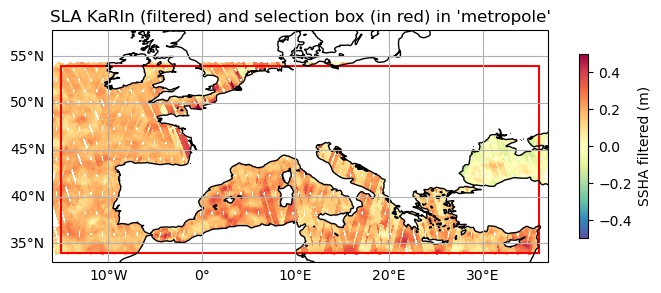

In [15]:
# Figure
localbox_cartopy = bbox[0] - 1, bbox[2] + 1, bbox[1] - 1, bbox[3] + 1
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.set_extent(localbox_cartopy)

plot_kwargs = dict(
    x="longitude",
    y="latitude",
    cmap="Spectral_r",
    vmin=-0.5,
    vmax=0.5,
    add_colorbar=False,  # Désactive la colorbar automatique
)

for pass_number in files["pass_number"]:
    ds = fc.query(area=area, pass_number=pass_number)
    # SWOT KaRIn SLA plots
    p = ds.ssha_filtered.plot.pcolormesh(ax=ax, **plot_kwargs)
    
fig.colorbar(p, ax=ax, shrink=0.3, label="SSHA filtered (m)")

ax.set_title(f"SLA KaRIn (filtered) and selection box (in red) in '{area}'")
ax.coastlines()
ax.gridlines(draw_labels=['left', 'bottom'])

# Add the patch to the Axes
rect = patches.Rectangle((bbox[0], bbox[1]), bbox[2] - bbox[0], bbox[3] - bbox[1], linewidth=1.5, edgecolor='r', facecolor='none')
ax.add_patch(rect)